# Random Forest Regression


In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('preprocessed_data.csv')
df.shape



(2013, 22)

### Подготовка данных



In [104]:
numeric_features = [
    'diagonal_inches', 'PPI', 'frequency_hz',
    'contrast_ratio', 'brightness_cd', 'response_time_ms',
    'aspect_ratio'
]

categorical_features = ['matrix_type', 'brand']

df_encoded = pd.get_dummies(df, columns=categorical_features, dummy_na=False, drop_first=True)

y = df_encoded['log_target']

features_to_use = [col for col in df_encoded.columns
                   if col in numeric_features or
                   col.startswith(tuple(cat + '_' for cat in categorical_features))]

X = df_encoded[features_to_use]

print(f"\nКоличество признаков: {len(features_to_use)}")
print(f"Колонки (first 20): {features_to_use[:20]}")




Количество признаков: 59
Колонки (first 20): ['diagonal_inches', 'aspect_ratio', 'PPI', 'frequency_hz', 'contrast_ratio', 'brightness_cd', 'response_time_ms', 'matrix_type_OLED', 'matrix_type_Other', 'matrix_type_TN', 'matrix_type_Unknown', 'matrix_type_VA', 'brand_AOC', 'brand_ASRock', 'brand_Acer', 'brand_Arzopa', 'brand_Asus', 'brand_BenQ', 'brand_Cooler Master', 'brand_Corsair']


### Разделение на тест и валид

70/15/15



In [105]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42
)

print(f"Train: {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test: {X_test.shape}")



Train: (1409, 59)
Validation: (302, 59)
Test: (302, 59)


### Baseline



In [106]:
baseline_pred_log = np.full(len(y_val), y_train.mean())
baseline_pred = np.expm1(baseline_pred_log)
y_val_true = np.expm1(y_val)

baseline_mae = mean_absolute_error(y_val_true, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_val_true, baseline_pred))
baseline_r2 = r2_score(y_val_true, baseline_pred)

print(f"Baseline:")
print(f"  MAE: {baseline_mae:.2f}")
print(f"  RMSE: {baseline_rmse:.2f}")
print(f"  R²: {baseline_r2:.4f}")



Baseline:
  MAE: 15001.88
  RMSE: 20547.63
  R²: -0.0711


### Проверка модели до подбора гиперпараметров



In [107]:
rf_initial = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_initial.fit(X_train, y_train)

y_val_pred_log = rf_initial.predict(X_val)
y_val_pred = np.expm1(y_val_pred_log)

mae_initial = mean_absolute_error(y_val_true, y_val_pred)
rmse_initial = np.sqrt(mean_squared_error(y_val_true, y_val_pred))
r2_initial = r2_score(y_val_true, y_val_pred)

print(f"  MAE: {mae_initial:.2f}")
print(f"  RMSE: {rmse_initial:.2f}")
print(f"  R²: {r2_initial:.4f}")
print(f"\nУлучшение по сравнению с baseline: {((baseline_mae - mae_initial) / baseline_mae * 100):.2f}%")



  MAE: 8172.29
  RMSE: 12183.15
  R²: 0.6234

Улучшение по сравнению с baseline: 45.52%


###  Перебор гиперпараметров

Тюним: n_estimators, max_depth, min_samples_split, min_samples_leaf, max_features



In [108]:
param_grid = {
    'n_estimators': [200, 250, 500, 700],
    'max_depth': [5, 10, 14, 16, 18],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': [0.5, 0.7, 0.9],
    'bootstrap': [True],
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
)

grid_search.fit(X_val, y_val)

print(f"\nЛучшие параметры: {grid_search.best_params_}")




Лучшие параметры: {'bootstrap': True, 'max_depth': 16, 'max_features': 0.5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}


### Проверка лучшей модели



In [109]:
best_rf = grid_search.best_estimator_

y_val_pred_log = best_rf.predict(X_val)
y_val_pred = np.expm1(y_val_pred_log)

mae_val = mean_absolute_error(y_val_true, y_val_pred)
rmse_val = np.sqrt(mean_squared_error(y_val_true, y_val_pred))
r2_val = r2_score(y_val_true, y_val_pred)

print(f"Validation:")
print(f"  MAE: {mae_val:.2f}")
print(f"  RMSE: {rmse_val:.2f}")
print(f"  R²: {r2_val:.4f}")


y_test_pred_log = best_rf.predict(X_test)
y_test_pred = np.expm1(y_test_pred_log)
y_test_true = np.expm1(y_test)

mae_test = mean_absolute_error(y_test_true, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test_true, y_test_pred))
r2_test = r2_score(y_test_true, y_test_pred)

print(f"\nTest Set:")
print(f"  MAE: {mae_test:.2f}")
print(f"  RMSE: {rmse_test:.2f}")
print(f"  R²: {r2_test:.4f}")


y_test_pred_log = best_rf.predict(X_train)
y_test_pred = np.expm1(y_test_pred_log)
y_test_true = np.expm1(y_train)

mae_test = mean_absolute_error(y_test_true, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test_true, y_test_pred))
r2_test = r2_score(y_test_true, y_test_pred)

print(f"\nTrain:")
print(f"  MAE: {mae_test:.2f}")
print(f"  RMSE: {rmse_test:.2f}")
print(f"  R²: {r2_test:.4f}")

Validation:
  MAE: 5636.91
  RMSE: 8604.69
  R²: 0.8122

Test Set:
  MAE: 9496.89
  RMSE: 14504.90
  R²: 0.4625

Train:
  MAE: 10115.68
  RMSE: 14609.99
  R²: 0.5573


### Анализ Feature Importance




Топ 20 признаков:
             Feature  Importance
5      brightness_cd    0.273990
0    diagonal_inches    0.213884
2                PPI    0.130708
4     contrast_ratio    0.075398
6   response_time_ms    0.073258
3       frequency_hz    0.067869
7   matrix_type_OLED    0.042793
1       aspect_ratio    0.022707
33          brand_LG    0.013681
11    matrix_type_VA    0.011129
22        brand_Eizo    0.007498
9     matrix_type_TN    0.007352
21        brand_Dell    0.006209
28      brand_Iiyama    0.006101
12         brand_AOC    0.006014
15      brand_Arzopa    0.005602
39       brand_Neovo    0.004963
41     brand_Philips    0.004778
14        brand_Acer    0.004348
16        brand_Asus    0.003791


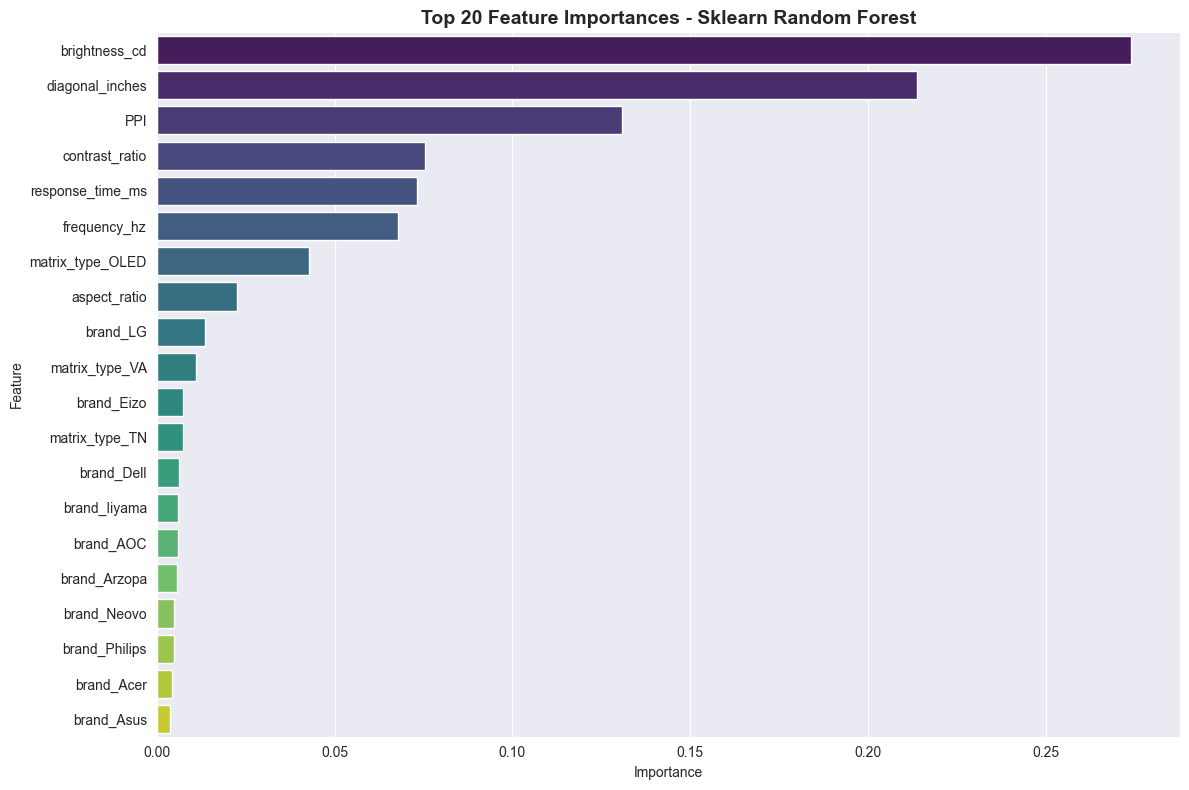

In [110]:
importances = best_rf.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': features_to_use,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\nТоп 20 признаков:")
print(feature_importance_df.head(20))

plt.figure(figsize=(12, 8))
top_n = 20
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(top_n), palette='viridis')
plt.title(f'Top {top_n} Feature Importances - Sklearn Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()



### Визуализация предиктов



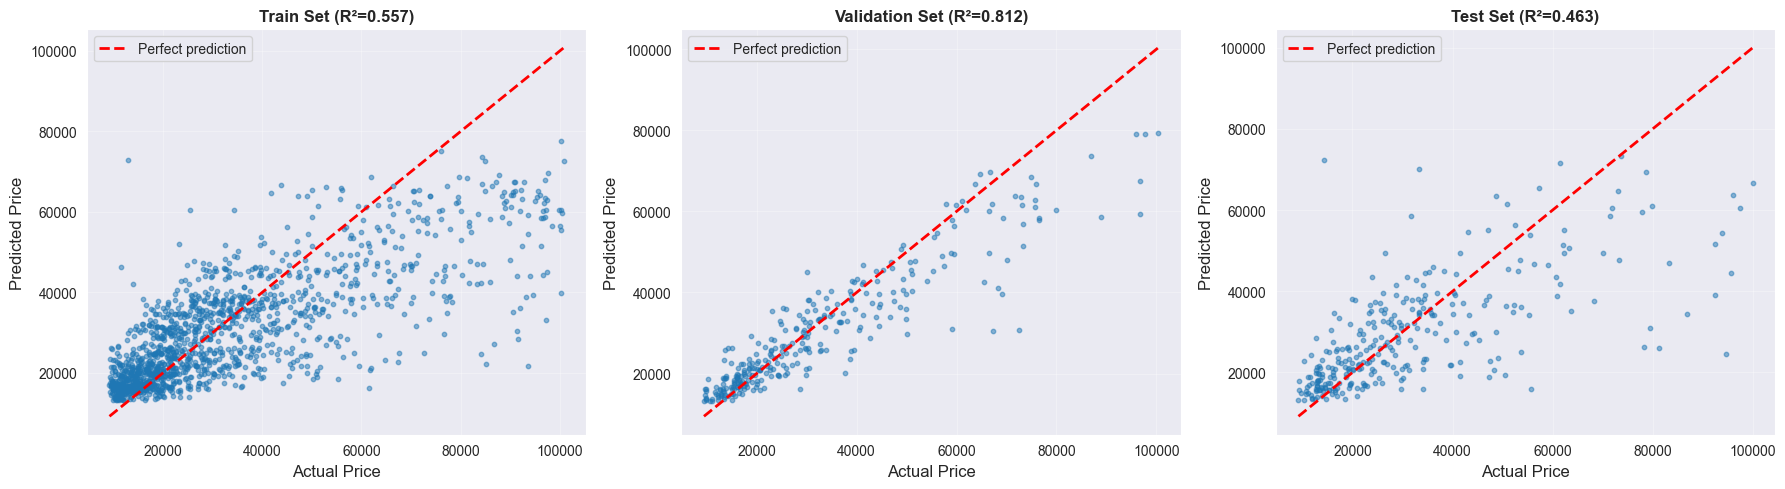

In [111]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

datasets = [
    (X_train, y_train, 'Train'),
    (X_val, y_val, 'Validation'),
    (X_test, y_test, 'Test')
]

for ax, (X, y, name) in zip(axes, datasets):
    y_pred_log = best_rf.predict(X)
    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y)

    ax.scatter(y_true, y_pred, alpha=0.5, s=10)
    ax.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()],
            'r--', lw=2, label='Perfect prediction')
    ax.set_xlabel('Actual Price', fontsize=12)
    ax.set_ylabel('Predicted Price', fontsize=12)
    ax.set_title(f'{name} Set (R²={r2_score(y_true, y_pred):.3f})', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

